# 1. Import Required Liraries 

In [31]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from mplsoccer import Pitch, Sbopen, VerticalPitch

# 2. Open the Dataset 

We need to filter games in which Ivory Coast played as either home or away team.
We also need to calculate the number of games so that we can normalize the diagrams when working on the solution later on:

In [7]:
# Open the data
parser = Sbopen()
df_match  = parser.match(competition_id=1267, season_id=107)
# Team we want is Ivory Coast 
team = "Côte d'Ivoire"

In [8]:
# List of Ivory Coast games - home or away
match_ids = df_match.loc[(df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)]["match_id"].tolist()

# Calculate the No. of games 
games_number = len(match_ids)


## 2.1 Finding the Danger Passes 

Steps:
1. For each game open event data using mplsoccer parser. Use the [0] to store only event data.
2. Extract all the shots the games and their time in seconds and possesion identifier.
3. Calculate the time difference between the pass and the shot. Keep only the passes made 15 seconds before the shot.

Note, that some possessions may have multiple shots, so we have to make sure to only include the passes in those possessions once, with the shot information of the upcoming shot:


In [10]:
# Open and concatenate event data for all matches 
df_all_events = pd.DataFrame()
for match_id in match_ids:
    df_events = parser.event(match_id)[0]
    df_all_events = pd.concat([df_all_events, df_events])

In [13]:
#Identify danger passes and add secs column
df_all_events["time_seconds"] = df_all_events["minute"]*60 + df_all_events["second"]

#Take out the shots
df_shots = df_all_events[(df_all_events['type_name'] == 'Shot')]

#Only keep the necessary columns about shots
df_shots = df_shots[['match_id', 'possession', 'time_seconds']]

#Take out the open play successful passes from the possession team
df_passes = df_all_events[(df_all_events['type_name'] == 'Pass') 
                          & (df_all_events['outcome_name'].isnull()) 
                          & (df_all_events['possession_team_id'] == df_all_events['team_id'])
                          & (~df_all_events.sub_type_name.isin(['Throw-in','Corner','Free Kick', 'Kick Off', 'Goal Kick']))
                          ]
# Merge shots and passes on possession and match_id
# Use a inner join to keep only passes that have a matching shot in the same possession  
df_merged = df_shots.merge(df_passes, on=['possession', 'match_id'], how='inner',suffixes=('_shot',''))

# Calculate time difference between pass and shot
df_merged['time_diff'] = df_merged['time_seconds_shot'] - df_merged['time_seconds']

# Keep only passes that occurred within 15 seconds before the shot
df_danger_passes = df_merged[df_merged['time_diff'].between(0,15)]

# Some possessions may have multiple shots, keep only the shot with the smallest time_diff to each pass
first_shot = df_danger_passes.groupby('id')['time_diff'].idxmin()
df_danger_passes = df_danger_passes.loc[first_shot].reset_index(drop=True)

# Filter for our team
df_danger_passes = df_danger_passes[df_danger_passes['team_name'] == team]

# Only keep necessary columns
danger_passes = df_danger_passes[['x', 'y', 'end_x', 'end_y', 'minute','second','player_name']]

# 2.2 Ploting the Location of Danger Passes 

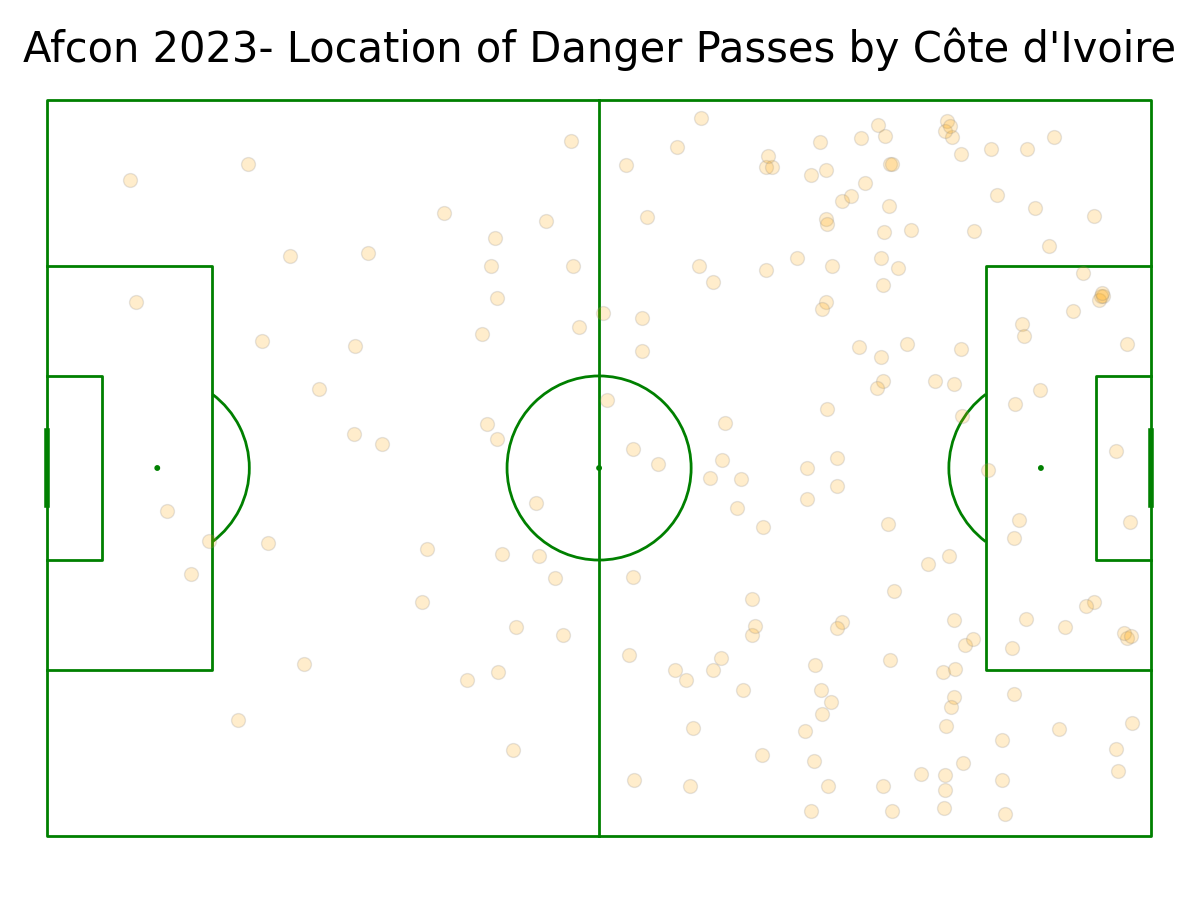

In [21]:
#plot pitch
pitch = Pitch(line_color='green')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

#scatter the location on the pitch
pitch.scatter(danger_passes.x, danger_passes.y, s=100, color='orange', edgecolors='grey', linewidth=1, alpha=0.2, ax=ax["pitch"])

#uncomment it to plot arrows
#pitch.arrows(danger_passes.x, danger_passes.y, danger_passes.end_x, danger_passes.end_y, color = "orange", ax=ax['pitch'])
#add title
fig.suptitle('Afcon 2023- Location of Danger Passes by ' + team, fontsize = 30)
plt.show()

## 2.3 Making a Heat Map

Steps:
1. Draw a pitch
2. Calculate the number of passes in each bin using bin_statistic()
3. Normalize the number of passes by number of games
4. Plot a heat map and make the legend

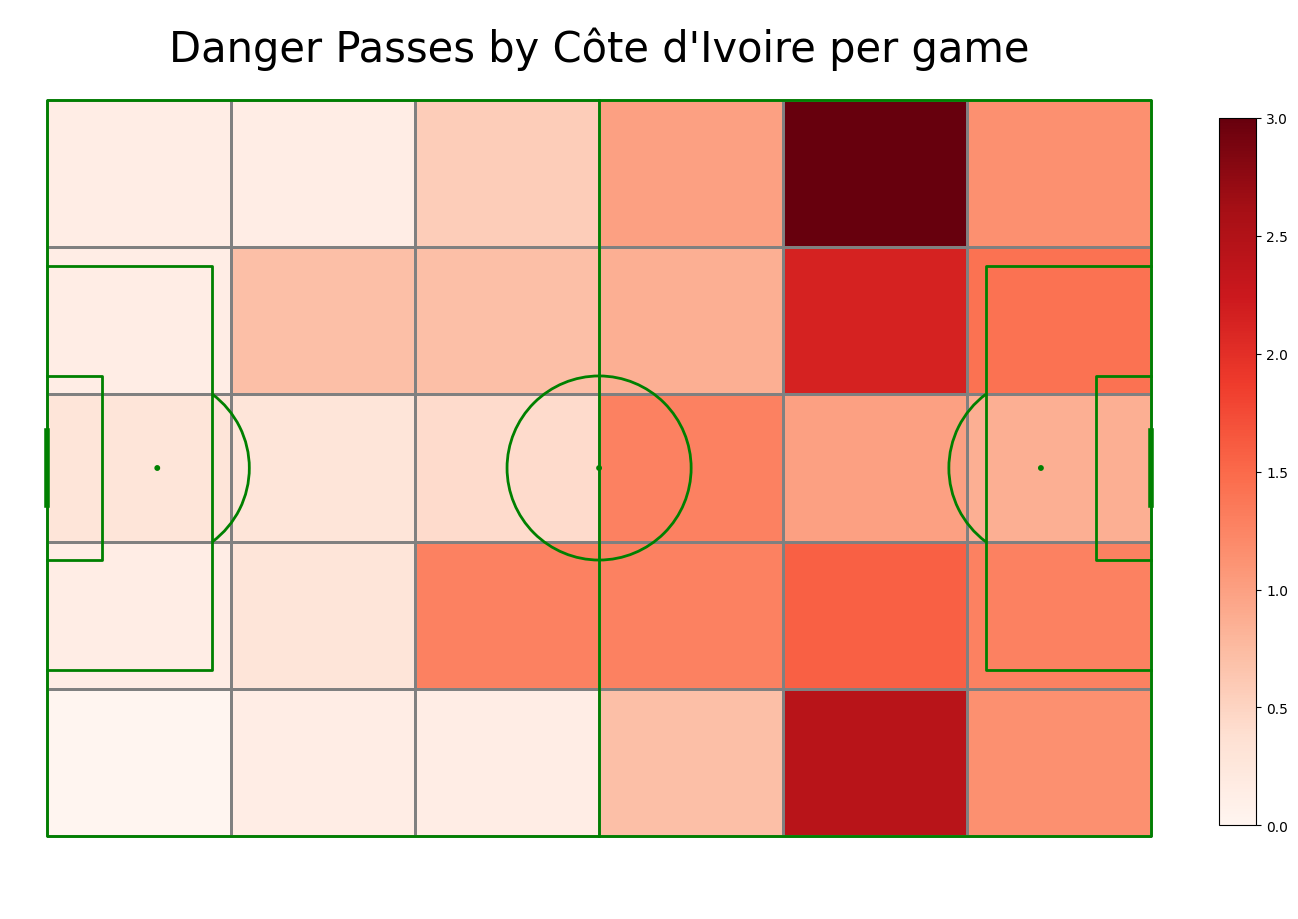

In [27]:
# Plot vertical pitch
pitch = Pitch(line_zorder=2, line_color='green')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

# Get the 2D histogram 
bin_statistic = pitch.bin_statistic(danger_passes.x, danger_passes.y, statistic='count', bins=(6, 5), normalize=False)

# Normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/games_number

# Make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])

#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger Passes by ' + team + " per game", fontsize = 30)
plt.show()

## 2.4 Diagram of Most Involved Players 

Steps:
1. To find out who was the most involved in dnager passes, we keep only surnames of players to make the vizualisation clearer.
2. Group the passes by the player and count them.
3. Divide them by number of games to keep the diagram per game.
4. Make the legend

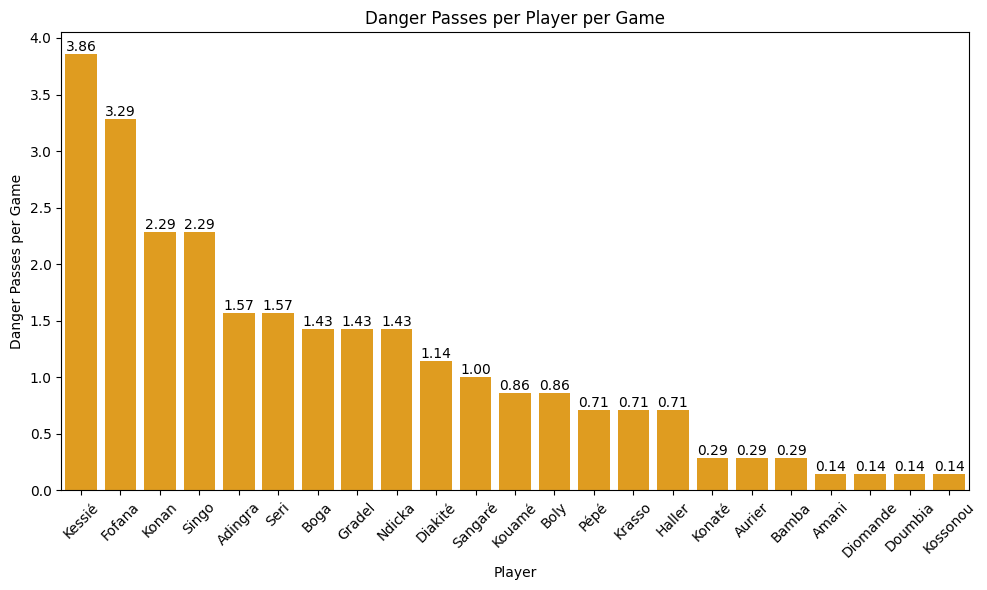

In [34]:

# Work on a safe copy
danger_passes = danger_passes.copy()

# Keep only surnames ---
danger_passes["player_name"] = (
    danger_passes["player_name"]
    .astype(str)
    .str.split()
    .str[-1]
)

# Group by player and count passes ---
player_passes = (
    danger_passes
    .groupby("player_name")
    .size()
    .reset_index(name="danger_passes")
)

# Convert to per game values ---
player_passes["danger_passes_per_game"] = (
    player_passes["danger_passes"] / games_number
)

# Sort descending ---
player_passes = player_passes.sort_values(
    by="danger_passes_per_game",
    ascending=False
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=player_passes,
    x="player_name",
    y="danger_passes_per_game",
    color="orange"
)

plt.xticks(rotation=45)
plt.xlabel("Player")
plt.ylabel("Danger Passes per Game")
plt.title("Danger Passes per Player per Game")

# Add values on top of bars 
for index, value in enumerate(player_passes["danger_passes_per_game"]):
    plt.text(index, value, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [35]:
# @ To do: Make a heat map for most involved player only: